# 4-3 과제 해설

건포도 품종 분류기 만들기

---

오늘은 **정답을 알려주는 시간이 아님.**

여러분이 **각자 다른 답**을 가져왔음.

---

측정값 7개 중 2개를 고르는 조합은?

## **7 × 6 ÷ 2 = 21가지**

`Perimeter + Eccentricity` 와 `Eccentricity + Perimeter` 는 같은 조합.
**순서는 상관없음.**

---

# 틀린 부분이 있는 게 정상

혼자 푸는 과제였음. **막혔을 때 물어볼 사람이 없었음.**

오늘 제가 **"이렇게 한 사람?"** 이라고 물으면
**틀렸어도 편하게 손 들어주셈.**

> ### 점수 안 매김. 제출도 그냥 받기만 했음
> ### 틀린 걸 찾아서 고치는 게 오늘 목적임

## 데이터 준비

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# 데이터: UCI Machine Learning Repository — Raisin (id=850), CC BY 4.0
try:
    from ucimlrepo import fetch_ucirepo
    df = fetch_ucirepo(id=850).data.original
    print("데이터: UCI 에서 직접 받음")
except Exception as e:
    df = pd.read_csv("raisin.csv")          # 인터넷이 안 되면 옆에 둔 파일
    print("데이터: raisin.csv 에서 읽음 -", type(e).__name__)

# train 576 / validation 144 / test 180
dev, test_df = train_test_split(df, test_size=0.2, stratify=df["Class"], random_state=42)
train_df, valid_df = train_test_split(dev, test_size=0.2, stratify=dev["Class"], random_state=42)
y_train, y_valid, y_test = train_df["Class"], valid_df["Class"], test_df["Class"]

FEATURES = [c for c in df.columns if c != "Class"]


def plot_pair(f1, f2):
    """train 576행으로 두 측정값 산점도를 그림 — 쓰고 싶으면 쓰셈"""
    for label, g in train_df.groupby("Class"):
        plt.scatter(g[f1], g[f2], s=20, alpha=.55, label=label)
    plt.xlabel(f1); plt.ylabel(f2); plt.legend(); plt.grid(alpha=.15)
    plt.title(f"{f1} vs {f2}  (train)")
    plt.show()


print("train", len(train_df), "/ validation", len(valid_df), "/ test", len(test_df))
print("class", dict(df["Class"].value_counts()))
print("features", FEATURES)
print("baseline(찍기)", 0.5)


데이터: UCI 에서 직접 받음
train 576 / validation 144 / test 180
class {'Kecimen': np.int64(450), 'Besni': np.int64(450)}
features ['Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity', 'ConvexArea', 'Extent', 'Perimeter']
baseline(찍기) 0.5


---

## 측정값 7개가 각각 무엇인가

터키에서 재배한 건포도 900알을 **카메라로 찍어서** 이미지 처리로 뽑아낸 값들임.
그래서 넓이·길이 단위가 **픽셀**임.

| 측정값 | 무엇을 재는가 | 대략 범위 |
|---|---|---|
| `Area` | 건포도 안쪽 **픽셀 개수** = 넓이 | 25,000 ~ 235,000 |
| `Perimeter` | 건포도 **둘레** 길이 | 619 ~ 2,698 |
| `MajorAxisLength` | 건포도에 그을 수 있는 **가장 긴 선** | 226 ~ 997 |
| `MinorAxisLength` | 그에 수직인 **가장 짧은 선** | 144 ~ 492 |
| `ConvexArea` | 건포도를 감싸는 **가장 작은 볼록 도형**의 넓이 | 26,000 ~ 278,000 |
| `Eccentricity` | **얼마나 길쭉한가.** 0이면 완전한 원, 1에 가까울수록 납작한 타원 | 0.35 ~ 0.96 |
| `Extent` | 건포도를 감싸는 **사각형 대비 건포도가 차지한 비율.** 얼마나 꽉 찼나 | 0.38 ~ 0.84 |

**`Class`** 가 정답임. `Kecimen` 과 `Besni`, 터키 건포도 두 품종.

---

### 표를 볼 때 짚어둘 것

**범위를 비교해보셈.**

- `Area` 는 **만 단위**임
- `Eccentricity` 와 `Extent` 는 **0에서 1 사이**임

**만 단위와 소수점을 같이 놓고 "거리"를 재면 무슨 일이 생길까?**

4-2 에서 배운 게 여기서 그대로 쓰임. 문제 3 에서 확인하게 됨.

---

### 비슷해 보이는 것끼리

- `Area` 와 `ConvexArea` — 둘 다 **넓이**임. 값도 비슷하게 움직임
- `MajorAxisLength` 와 `MinorAxisLength` — 둘 다 **길이**
- `Eccentricity` 와 `Extent` — 둘 다 **모양 비율**. 크기와 무관함

> **비슷한 둘을 같이 고르면 정보가 하나뿐일 수도 있음.**
> 서로 다른 성격을 섞는 게 나을지, 같은 성격끼리가 나을지 — 직접 골라보셈.

*출처: UCI Machine Learning Repository — Raisin (id 850)*
*Selçuk University 에서 CVS(Computer Vision System) 로 촬영·추출. CC BY 4.0*

In [2]:
# 측정값 7개의 실제 범위
display(df.drop(columns=["Class"]).describe().T[["min", "mean", "max"]].round(2))


,min,mean,max
Area,25387.00,87804.13,235047.00
MajorAxisLength,225.63,430.93,997.29
MinorAxisLength,143.71,254.49,492.28
Eccentricity,0.35,0.78,0.96
ConvexArea,26139.00,91186.09,278217.00
Extent,0.38,0.70,0.84
Perimeter,619.07,1165.91,2697.75


---

# 900개가 어떻게 나뉘었나

```
900
 ├─ 20% 떼기 →  test 180        ← 봉인
 └─ 720
     ├─ 20% 떼기 → validation 144
     └─            train      576
```

**576 + 144 = 720**, 거기에 **180** 을 더하면 **900**

---

# 왜 두 번 나눴나

**train 과 test 만 있다면?**

모델을 고를 때 볼 게 **test 밖에 없음.**

그런데 test 를 보면서 고르면
→ **test 는 더 이상 "처음 보는 데이터" 가 아님.**

> ### 그래서 중간에 하나를 더 만든 것
> **고를 때 쓰는 데이터 = validation**

---

# 세 개의 역할

| | 개수 | 역할 | 3-1 비유 |
|---|---:|---|---|
| **train** | 576 | 모델이 배움. `fit` 에 들어감 | **교과서** |
| **validation** | 144 | 고를 때 봄. LR vs KNN, k 선택 | **모의고사** |
| **test** | 180 | 다 고른 뒤 **딱 한 번** | **수능** |

> 교과서로 공부하고, 모의고사로 전략을 고치고, **수능은 한 번.**

---

# 기준선이 왜 0.5 인가

```
class {'Kecimen': 450, 'Besni': 450}
```

**두 품종이 정확히 반반.**

눈 감고 "다 Kecimen 이야" 라고 찍어도 → **절반은 맞음**

## 기준선 = **0.5000**

---

# 같은 0.8 대인데 의미가 다름

**4-1 타이타닉**
"남자면 사망" 한 줄 규칙 → **0.7978**
우리가 만든 로지스틱 → **0.7978**

> **"비교 대상이 없으면 좋은 숫자인지 알 수 없다"**

---

| | 기준선 | 점수 | 기준선 대비 |
|---|---:|---:|---:|
| 4-1 타이타닉 | 0.6162 | 0.798 | **+0.18** |
| **오늘 건포도** | **0.5000** | 0.86 | **+0.36** |

**오늘 데이터는 반반이라 찍기가 어려움.**

---
---

# 문제 1 — 측정값 2개 고르기

## 어떤 조합을 고르셨습니까?

---

# 왜 다 다를까

**정답을 안 정해놨기 때문.**

산점도를 보고 "덜 겹쳐 보이는" 조합을 고르라고 했음.
**눈으로 판단하는 거라 사람마다 다름.**

> ### 그리고 이게 실무와 같음
> 아무도 "이 두 개를 쓰세요" 라고 알려주지 않음.

---

# 산점도에서 뭘 봤어야 하나

**"두 색깔 점이 얼마나 갈라져 있나"**

| | 모양 |
|---|---|
| **좋은 조합** | 한쪽 구석에 한 색, 반대쪽에 다른 색. **겹치는 띠가 좁음** |
| **나쁜 조합** | 두 색이 뒤섞임. **어디를 잘라도 양쪽에 두 색이 다 있음** |

---

> # 겹친 구간은 어떤 모델을 써도 못 가름
> 로지스틱이든, KNN 이든, 딥러닝이든.
> **측정값이 같으면 그 두 건포도는 컴퓨터한테 똑같이 보임.**

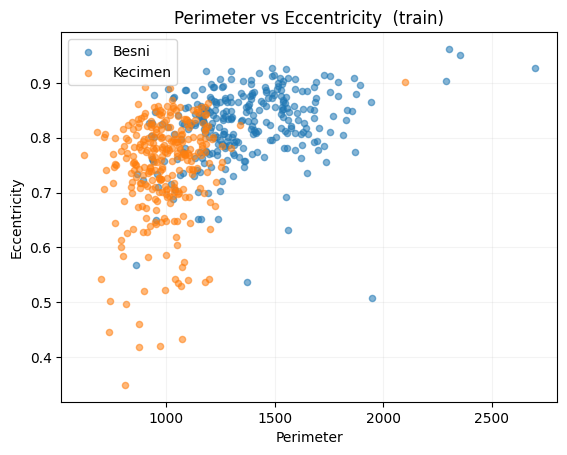

Perimeter + Eccentricity  train CV = 0.8454


In [3]:
F1, F2 = "Perimeter", "Eccentricity"
X_train, X_valid = train_df[[F1, F2]], valid_df[[F1, F2]]

plot_pair(F1, F2)
pair_cv = cross_val_score(
    Pipeline([("s", StandardScaler()), ("k", KNeighborsClassifier(5))]),
    X_train, y_train, cv=5).mean()
print(f"{F1} + {F2}  train CV = {pair_cv:.4f}")

In [4]:
import itertools

rows = []
for a, b in itertools.combinations(FEATURES, 2):
    Xt, Xv = train_df[[a, b]], valid_df[[a, b]]
    cvm = cross_val_score(Pipeline([("s", StandardScaler()),
                                    ("k", KNeighborsClassifier(5))]),
                          Xt, y_train, cv=5).mean()
    _lr = LogisticRegression(max_iter=5000).fit(Xt, y_train)
    _kr = KNeighborsClassifier(5).fit(Xt, y_train)
    _sc = StandardScaler(); Xts = _sc.fit_transform(Xt); Xvs = _sc.transform(Xv)
    _ks = KNeighborsClassifier(5).fit(Xts, y_train)
    _g = GridSearchCV(Pipeline([("s", StandardScaler()), ("k", KNeighborsClassifier())]),
                      {"k__n_neighbors": [3, 5, 7, 9, 11, 15]}, cv=5).fit(Xt, y_train)
    rows.append([f"{a} + {b}", round(cvm, 4),
                 round(_lr.score(Xv, y_valid), 4), round(_kr.score(Xv, y_valid), 4),
                 round(_ks.score(Xvs, y_valid), 4),
                 int((_kr.predict(Xv) != _ks.predict(Xvs)).sum()),
                 _g.best_params_["k__n_neighbors"],
                 round(accuracy_score(y_valid, _g.predict(Xv)), 4)])

pairs = pd.DataFrame(rows, columns=["pair", "trainCV", "LR", "KNNraw",
                                    "KNNscaled", "changed", "bestk", "tuned"])
pairs = pairs.sort_values("KNNscaled", ascending=False)
pd.set_option("display.width", 250)
print(pairs.to_string(index=False))
print()
print("scaled > raw :", int((pairs.KNNscaled > pairs.KNNraw).sum()), "/ 21",
      " | 악화:", int((pairs.KNNscaled < pairs.KNNraw).sum()),
      " | 동일:", int((pairs.KNNscaled == pairs.KNNraw).sum()))
print("LR > scaled  :", int((pairs.LR > pairs.KNNscaled).sum()), "/ 21")
print("tuned > k=5  :", int((pairs.tuned > pairs.KNNscaled).sum()),
      " | 낮음:", int((pairs.tuned < pairs.KNNscaled).sum()),
      " | 동일:", int((pairs.tuned == pairs.KNNscaled).sum()))
print("changed 폭   :", pairs.changed.min(), "~", pairs.changed.max())
print("best k 분포  :", dict(pairs.bestk.value_counts()))

                             pair  trainCV     LR  KNNraw  KNNscaled  changed  bestk  tuned
      MinorAxisLength + Perimeter   0.8472 0.8472  0.8681     0.8889       17      7 0.8889
              Area + Eccentricity   0.8264 0.8333  0.7500     0.8750       32     15 0.8611
        Eccentricity + ConvexArea   0.8298 0.8403  0.7778     0.8750       20      7 0.8889
               Extent + Perimeter   0.8125 0.8889  0.8611     0.8681       17     15 0.8819
   MinorAxisLength + Eccentricity   0.8403 0.8194  0.6111     0.8681       49     15 0.8750
         Eccentricity + Perimeter   0.8454 0.8750  0.8611     0.8681       19     15 0.8681
MajorAxisLength + MinorAxisLength   0.8281 0.8472  0.8681     0.8681        6     15 0.8681
   MajorAxisLength + Eccentricity   0.8281 0.8472  0.8056     0.8681       21     15 0.8681
     MinorAxisLength + ConvexArea   0.8229 0.8611  0.7778     0.8611       22     15 0.8750
           ConvexArea + Perimeter   0.8437 0.8750  0.7778     0.8542       25   

---

# 표 읽는 법

| 열 | 뜻 |
|---|---|
| `trainCV` | train 576개 안에서 교차검증한 점수 |
| `LR` | 로지스틱 회귀의 validation 점수 |
| `KNNraw` | **스케일링 안 한** KNN |
| `KNNscaled` | **스케일링한** KNN |
| `changed` | 스케일링으로 **예측이 바뀐 개수** |
| `bestk` | CV 가 고른 k |
| `tuned` | 그 k 로 만든 모델의 validation |

**`KNNscaled` 기준으로 정렬돼 있음. 자기 조합을 찾아보셈.**

---

# 성능 폭이 22%p

| | 조합 | KNNscaled |
|---|---|---:|
| 최고 | `MinorAxisLength + Perimeter` | **0.8889** |
| 최저 | `Eccentricity + Extent` | **0.6667** |

---

**둘 다 똑같은 KNN. k 도 5 로 같고, 스케일링도 똑같이 함.**
**코드가 글자 하나까지 같음.**

> # 차이는 오직 "어떤 측정값 2개를 골랐냐" 뿐

---

# 0.75 미만은 딱 두 조합

| 조합 | trainCV | KNNraw | KNNscaled | changed |
|---|---:|---:|---:|---:|
| `MinorAxisLength + Extent` | 0.7153 | 0.6250 | **0.7083** | 38 |
| `Eccentricity + Extent` | 0.6875 | 0.6944 | **0.6667** | 12 |

**두 조합 다 `Extent` 가 들어 있음. 우연이 아님.**

---

> ### 낮은 점수가 나온 게 잘못한 게 아님
> 21개 중 2개니까, 20명이면 **한두 명은 나오게 되어 있었음.**

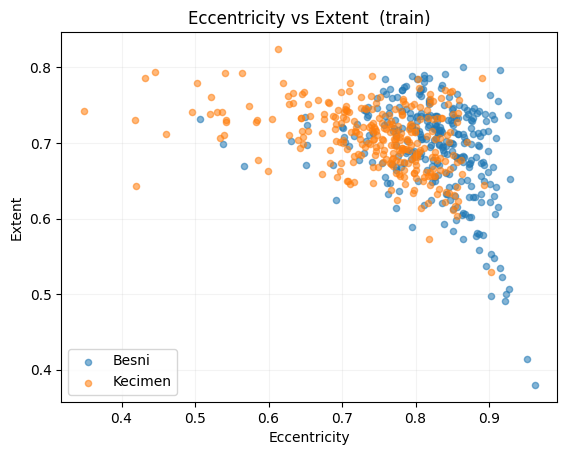

In [5]:
plot_pair("Eccentricity", "Extent")

---

# `Extent` 가 무엇인가

**건포도를 감싸는 사각형 대비 건포도가 차지한 비율**
= "얼마나 꽉 찼나"

---

> ### 이건 크기와 상관이 없음. 비율이니까
> 큰 건포도든 작은 건포도든, **모양이 비슷하면 `Extent` 가 비슷함.**

In [6]:
cls = df.groupby("Class").mean().T
cls["차이"] = (cls["Besni"] - cls["Kecimen"]).abs()
cls["범위대비"] = (cls["차이"] /
                 (df.drop(columns=["Class"]).max() - df.drop(columns=["Class"]).min()))
print(cls.round(3).sort_values("범위대비", ascending=False).to_string())
print()
print("→ 범위 대비 차이가 클수록 두 품종을 잘 가름")

Class                 Besni    Kecimen         차이   범위대비
Area             112194.789  63413.467  48781.322  0.233
MajorAxisLength     509.001    352.859    156.141  0.202
ConvexArea       116675.824  65696.356  50979.469  0.202
Perimeter          1348.127    983.686    364.441  0.175
MinorAxisLength     279.624    229.353     50.271  0.144
Eccentricity          0.821      0.742      0.079  0.129
Extent                0.691      0.708      0.017  0.036

→ 범위 대비 차이가 클수록 두 품종을 잘 가름


---

# `Extent` 만 예외였음

맨 오른쪽 **"범위대비"** = 두 품종 평균 차이 ÷ 전체 범위
**클수록 두 품종을 잘 가름.**

| 순위 | 측정값 | 범위대비 |
|---:|---|---:|
| 1 | `Area` | 0.233 |
| 2 | `MajorAxisLength` | 0.202 |
| ⋮ | | |
| 6 | `Eccentricity` | 0.129 |
| **7** | **`Extent`** | **0.036** |

**`Eccentricity` 의 4분의 1도 안 됨. 1위 `Area` 의 6분의 1.**

---

# 두 품종이 사실상 같은 값

| | Besni | Kecimen | 차이 |
|---|---:|---:|---:|
| `Extent` | 0.691 | 0.708 | **0.017** |

그런데 `Extent` 전체 범위는 **0.38 ~ 0.84** (폭 0.46)

> # 범위는 0.46 인데 두 품종 차이가 0.017

---

# 그래서 왜 낮았나

**`Extent` 가 품종을 가르는 정보를 거의 안 갖고 있음.**

측정값 2개를 넣었는데, **그중 하나가 사실상 빈 값.**

> ### 나머지 하나로만 판단한 셈
> **측정값 1개짜리 모델이었던 것.**

---

# 반대로 나머지는 왜 괜찮았나

| | Besni | Kecimen |
|---|---:|---:|
| `Area` | **112,194** | **63,413** |

**거의 두 배. Besni 가 Kecimen 보다 확실히 큰 품종임.**

그래서 크기 관련 측정값 — `Area`, `Perimeter`, 축 길이, `ConvexArea` —
**전부 두 품종을 잘 가름.**

`Eccentricity` 도 0.821 vs 0.742. **Besni 가 좀 더 길쭉함.**

> ### `Extent` 만 예외였던 것

---

# 문제 1 에서 이미 신호가 있었음

과제 안내에 이렇게 적혀 있었음:

> **"그 조합이 어느 정도인지 train 내부 CV 로 재보면 참고가 됨"**

`Eccentricity + Extent` 는 train CV 가 **0.6875**
다른 조합들은 대부분 **0.82 이상**

---

## 그럼 그때 조합을 바꿨어야 했나?

> ### 아님. 바꾸지 않은 게 맞음
> 그 낮은 숫자를 **"왜 낮은가" 로 풀어내는 게** 오늘 할 일이었음.
> 바꿔버렸으면 이 이야기를 못 했음.

---

> # 결론 ①
> ## 모델을 고르기 전에, 무엇을 입력할지가 먼저 결정된다

**4-2**: "KNN 을 잘 쓴다는 건 모델을 튜닝하는 게 아니라 **거리를 설계하는 일**이다"

오늘 그게 **22%p** 로 나타남.

---
---

# 서술 1 — 고른 이유

---

## ❌ 아쉬운 답

> "점수가 잘 나올 것 같아서"
> "많이 쓰는 것 같아서"

**근거가 아니라 느낌.** 산점도를 보라고 했는데 안 본 것.

---

## ⭕ 좋은 답

> "산점도에서 **`Perimeter` 축**을 따라 두 품종의 **중심이 눈에 띄게 달랐고**,
> **`Eccentricity`** 를 같이 보니 **겹치는 띠가 가운데로 좁아져서** 골랐음"

**축 이름이 나오고, 어떻게 갈렸는지가 나옴.**
나중에 다시 읽어도 **재현할 수 있음.**

---

# 근거의 조건

> ## 남이 읽고 확인할 수 있어야 함

| | |
|---|---|
| ❌ "느낌상 좋아 보여서" | 확인이 안 됨 |
| ⭕ "Perimeter 축에서 중심이 갈렸다" | **그림을 다시 그려보면 됨** |

**이게 오늘 계속 나올 "Evidence" 의 뜻.**

---
---

# 문제 2 — 로지스틱 회귀 vs KNN

## 어느 쪽이 이겼습니까?

In [7]:
lr = LogisticRegression(max_iter=5000).fit(X_train, y_train)
lr_pred = lr.predict(X_valid)
lr_acc = accuracy_score(y_valid, lr_pred)

knn = KNeighborsClassifier(n_neighbors=5).fit(X_train, y_train)
knn_pred = knn.predict(X_valid)
knn_acc = accuracy_score(y_valid, knn_pred)

print(f"LR         {lr_acc:.4f}   (기준선 대비 {lr_acc-0.5:+.4f})")
print(f"KNN k=5    {knn_acc:.4f}   (기준선 대비 {knn_acc-0.5:+.4f})")

LR         0.8750   (기준선 대비 +0.3750)
KNN k=5    0.8611   (기준선 대비 +0.3611)


---

# 스케일링 안 한 KNN 은 LR 한테 많이 짐

전수표의 `KNNraw` 열을 보셈. **0.61, 0.75, 0.77** 같은 숫자가 꽤 있음.

**LR 은 대부분 0.83 이상.**

---

# 왜 raw KNN 이 약한가

| 측정값 | 범위 |
|---|---|
| `Area` | 25,000 ~ 235,000 |
| `Eccentricity` | 0.35 ~ 0.96 |

거리는 **차이를 제곱해서 더함.**

- `Area` 에서 **1,000** 차이 → 제곱하면 **1,000,000**
- `Eccentricity` 에서 **0.3** 차이 → 제곱하면 **0.09**

---

> # 0.09 를 백만에 더하면 아무 일도 안 일어남
> `Eccentricity` 는 **넣었는데 계산에서 사라진 것.**

---

# 로지스틱은 왜 괜찮은가

## `z = w₁ × Area + w₂ × Eccentricity + b`

`Area` 가 몇만 단위면 → 모델이 **`w₁` 을 아주 작게** 만들면 됨
`Eccentricity` 가 작으면 → **`w₂` 를 크게** 만들면 됨

> ### 로지스틱은 단위 차이를 계수로 흡수함
> ### KNN 은 못 함. 계수가 없음

**4-2**: "KNN 은 어떤 피처가 중요한지 **스스로 배우지 않는다**"

그래서 스케일링이 KNN 에서 **"필수"** 인 것.

---

# 기준선 0.5 보다 낮은 사람은?

## **아무도 없음**

제일 낮은 조합도 raw KNN 이 **0.6111**
기준선보다 **0.11 높음**

> ### "완전히 못 배운 모델" 은 아니었음
> 나쁘긴 한데, **찍는 것보단 나음.**

---

> # 아직 승자를 정하지 않음

KNN 한테 **스케일링 기회를 안 줬음.**

## 공정한 비교가 아님

다음 문제에서 제대로 붙여봅시다.

---
---

# 문제 3 — 스케일링

## 예측이 하나라도 바뀐 사람?

---

# 하나도 안 바뀌었다면

**그건 스케일링이 안 된 것.**

KNN 에 넣은 데이터가 `X_train` 이었는지 `X_train_s` 였는지 보셈.

`X_train` 을 넣으면 → **문제 2 의 KNN 과 완전히 같은 모델**

> ### 점수가 소수점까지 똑같이 나왔다면 그게 신호
> 실측: 원본을 넣으면 raw KNN 과 **정확히 같은 0.8611**

---
> # 이게 원리임
> ## 조합과 무관하게 성립하는 것

KNN 은 거리로 판단하니까, **단위를 바꾸면 이웃이 바뀜.**
어떤 측정값을 쓰든 마찬가지.

---

# "이웃이 바뀐다" 는 게 무슨 뜻인가

건포도 하나를 분류함. KNN 은 **가장 가까운 5개**를 찾아 다수결.

| | 뽑히는 이웃 |
|---|---|
| **스케일링 전** | `Area` 가 거리를 지배 → **"Area 가 비슷한 5개"** |
| **스케일링 후** | 둘이 같은 무게 → **"둘 다 비슷한 5개"** |

---

> 답이 바뀌는 게 당연함.

In [8]:
sc_ = StandardScaler()
X_train_s = sc_.fit_transform(X_train)     # train 에는 fit_transform
X_valid_s = sc_.transform(X_valid)         # validation 에는 transform

knn_s = KNeighborsClassifier(n_neighbors=5).fit(X_train_s, y_train)
pred_s = knn_s.predict(X_valid_s)
scaled_acc = accuracy_score(y_valid, pred_s)
changed = int((knn_pred != pred_s).sum())

print(f"스케일링 전  {knn_acc:.4f}")
print(f"스케일링 후  {scaled_acc:.4f}")
print(f"예측이 바뀐 건포도  {changed} / {len(y_valid)}")

스케일링 전  0.8611
스케일링 후  0.8681
예측이 바뀐 건포도  19 / 144


---

# 바뀐 개수 폭: **2 ~ 49개**

validation 이 144개니까, **49개면 34%.** 셋 중 하나가 답이 바뀐 것.

| 조합 | changed | KNNraw → KNNscaled |
|---|---:|---|
| `MinorAxisLength + Eccentricity` | **49** | 0.6111 → **0.8681** |
| `Area + ConvexArea` | **2** | 0.8472 → 0.8333 |

---

**2개인 조합** — `Area` 와 `ConvexArea` 는 둘 다 넓이.
**87,524 와 90,546 처럼 단위가 이미 비슷함.**
단위가 비슷하면 스케일링해도 거리가 크게 안 바뀜.

> ### 스케일링 효과는 조합마다 다름. 2개부터 49개까지.

---

# 49개 바뀐 조합

## `MinorAxisLength + Eccentricity`

| | 점수 |
|---|---:|
| `KNNraw` | **0.6111** |
| `KNNscaled` | **0.8681** |

> # 0.26 이 올랐음. 스케일링 하나로.

---

# 왜 이 조합에서 유독 컸나

| 측정값 | 값의 예 |
|---|---|
| `MinorAxisLength` | 253, 243, 266 — **수백 단위** |
| `Eccentricity` | 0.82, 0.80, 0.79 — **0 ~ 1** |

**대략 300배 차이. 제곱하면 9만 배.**

---

> ### 스케일링 전에는 사실상 `MinorAxisLength` 하나만 보고 판단
> 측정값을 2개 넣었는데 **1개만 쓴 셈.** 그래서 0.6111.
>
> 스케일링을 하니까 **비로소 `Eccentricity` 가 보이기 시작한 것.**

---

# 스케일링해서 **나빠진** 조합

| 조합 | KNNraw | KNNscaled |
|---|---:|---:|
| `Eccentricity + Extent` | 0.6944 | **0.6667** |
| `Area + ConvexArea` | 0.8472 | **0.8333** |

---

# 왜 나빠질 수 있나

## `Area + ConvexArea` 를 보면

- `Area` = 건포도 넓이
- `ConvexArea` = 감싸는 볼록 도형의 넓이

**둘이 거의 같은 걸 재고 있음.** 실제로 87,524 와 90,546.

---

> ### 이 조합은 사실상 정보가 하나뿐
> 둘 다 "크기" 를 재고 있음.
>
> 스케일링하면 두 개를 같은 무게로 보게 되는데
> **같은 정보를 두 번 세는 셈.**

*(이건 가설임. 확인하려면 더 실험해야 함)*

---

> # 스케일링은 정확도를 올리는 마법이 아님
> # 거리의 기준을 바꾸는 전처리임

기준이 바뀌면 **대체로** 좋아지지만, **항상은 아님.**


---

# 그럼 해야 하나? — **합니다**

안 하면 **측정값 하나가 무시됨.**

스케일링 안 하면 `Eccentricity` 가 계산에서 사라졌음.

> ### "2개를 넣었는데 1개만 쓰는 상태" 를 두는 게 이상한 것
> 점수가 조금 떨어지더라도, **넣은 걸 다 쓰는 게 맞음.**

**4-2 슬라이드**: 스케일링은 **"필수 전제조건"**

---

# `fit_transform` vs `transform`

## validation 에 뭘 쓰셨습니까?

---

# 왜 안 되는가

| 메서드 | 하는 일 |
|---|---|
| `fit` | **평균과 표준편차를 계산** |
| `transform` | 그 값으로 **변환만** |

validation 에 `fit_transform` 을 쓰면
→ **validation 의 평균과 표준편차를 계산해서 쓰는 것**

---

**실무에서 새 건포도 하나가 들어왔다면?**
그 하나로 평균을 계산할 수 있나? → **없음**

> ### train 에서 계산한 값을 써야 함. 그게 유일하게 가능한 방법.

---

# 실측

```
정답 (transform)       : 0.8681
오답 (fit_transform)   : 0.8542
```

**0.0139 차이. 약 2명.**

---

> # 에러가 안 남
> 그냥 조금 다른 숫자가 나옴. **모르고 넘어가면 평생 모름.**

**3-1**: "fit 괄호 안을 보는 습관" 을 그렇게 강조한 이유.

---

# 왜 두 가지를 확인하라고 했나

```
스케일링 전  0.8611
스케일링 후  0.8681        ← 0.007 올랐음
예측이 바뀐 건포도  19 / 144  ← 13% 가 바뀌었음
```

**정확도만 보면 "별거 아니네" 싶음.**

> ### 그런데 모델이 완전히 다른 판단을 하고 있음

---

# 왜 점수만 비슷했나

바뀐 19개 중에 **맞게 바뀐 것과 틀리게 바뀐 것이 섞여 있음.**

```
틀린 걸 맞게 바꾼 게   10개
맞은 걸 틀리게 바꾼 게   9개
────────────────────────
순증                    1개  →  정확도로는 0.007
```

---

> # 정확도는 "순증" 만 보여줌
> **"얼마나 많이 움직였는지" 는 안 보여줌.**

**3-2**: "지표 하나로 판단하지 않는다"

---
---

# 서술 2 — 스케일링 전후

---

## ❌ 아쉬운 답

> "스케일링하니까 점수가 올랐다"

**절반만 쓴 것.** 두 가지를 확인하라고 했는데 하나만 썼음.

---

> "스케일링은 KNN 에서 필수다"

**이건 제가 강의에서 한 말이지 여러분이 확인한 게 아님.**

> ### 서술란에는 **여러분이 본 것** 을 쓰는 것

---

## ⭕ 좋은 답

> "정확도는 **0.8611 → 0.8681** 로 0.007 올랐음.
> 그런데 validation 144개 중 **19개, 약 13%** 의 예측이 바뀌었음.
> **점수 변화는 작지만 모델의 판단 자체는 꽤 달라졌다고 봄.**"

---

**숫자가 두 개 있고, 그 둘을 연결해서 해석했음.**

> ### 숫자를 나열만 하면 그건 기록이지 해석이 아님

---
---

# 문제 4 — k 고르기

## 어떤 후보를 넣으셨습니까?

---

# 후보에 **1** 을 넣었다면

**가장 가까운 한 명한테만 물어보는 것.**

**4-2**: train 정확도는 **1.000** 이 나옴 — 자기 자신이 이웃이니까.

그런데 CV 에서는? → **보통 낮게 나옴.**
**이상한 이웃 한 명한테 휘둘리기 때문.**

---

# CV 가 뭐였죠

**교차검증.** 2회차에서 배웠음.

우리는 `cv=5` 를 썼음 → **train 576개를 5조각으로 나눔**

## 576 ÷ 5 ≈ **115개씩**

---

# CV 가 하는 일

```
1번 조각 빼고 나머지 4조각으로 학습 → 1번으로 채점
2번 조각 빼고 나머지 4조각으로 학습 → 2번으로 채점
3번 …
4번 …
5번 …
────────────────────────────────
그 5개 점수의 평균 = CV 점수
```

---

# 왜 validation 이 아니라 CV 로 골랐나

## ① validation 은 144개뿐

k 후보가 6개면 **144개짜리 시험을 6번** 보는 것.
한 명 틀리면 **0.007** 이 움직임.

→ **"우연히 잘 나온 k" 를 고를 위험이 큼**

---

## ② 더 중요한 것

k 를 고르는 데 validation 을 쓰면
**validation 도 "고르는 데 쓴 데이터" 가 됨.**

그러면 문제 5 에서 모델을 비교할 때 **공정하지 않음.**

> ### k 는 train 안에서 고르고, validation 은 모델 비교용으로 아껴둔 것

---

# Pipeline 이 왜 필요한가

CV 는 5번 나눔. **그때마다 학습용 4조각이 달라짐.**
→ **평균과 표준편차도 매번 달라져야 함**

---

**Pipeline 없이 미리 576개 전체로 스케일링하면?**

각 fold 의 채점용 조각이 **이미 평균 계산에 참여한 것.**

> # 아까 그 `fit_transform` 문제가 CV 안에서 5번 일어남

Pipeline 을 쓰면 sklearn 이 **fold 마다 다시 fit** 함.

---

# 그래서 `X_train` 을 그대로 넣음

Pipeline 안에 scaler 가 들어 있으니까.

---

**`X_train_s` 를 넣었다면?**

스케일링이 **두 번** 됨. 이미 한 걸 또 하는 것.

> ### 그런데 결과가 거의 같게 나옴
> 표준화한 걸 또 표준화해도 값이 크게 안 변함.
>
> **그래서 더 위험함. 틀렸는데 티가 안 남.**

In [9]:
K_LIST = [3, 5, 7, 9, 11, 15]
pipe = Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier())])
grid = GridSearchCV(pipe, {"knn__n_neighbors": K_LIST}, cv=5).fit(X_train, y_train)

best_k = grid.best_params_["knn__n_neighbors"]
tuned_acc = accuracy_score(y_valid, grid.predict(X_valid))

print(f"후보        {K_LIST}")
print(f"고른 k      {best_k}   (train CV {grid.best_score_:.4f})")
print(f"validation  {tuned_acc:.4f}   (k=5 였을 때 {scaled_acc:.4f})")

후보        [3, 5, 7, 9, 11, 15]
고른 k      15   (train CV 0.8594)
validation  0.8681   (k=5 였을 때 0.8681)


---

# 21개 조합의 best k 분포

| k | 개수 |
|---:|---:|
| **15** | **12** |
| 11 | 5 |
| 7 | 2 |
| 5 | 2 |

**큰 쪽으로 몰려 있음.**

---

# 왜 큰 k 인가

## ① train 576개인데 측정값을 2개만 씀

**2차원 평면에 576개 점.** 꽤 촘촘함.
이웃을 15명 봐도 여전히 **"가까운" 사람들.**

> **4-2 의 차원의 저주가 여기선 안 걸림. 2차원이니까.**

---

## ② 두 품종이 겹치는 구간이 넓음

겹치는 데서는 이웃 몇 명이 반대 라벨일 수밖에 없음.
→ **많이 물어봐서 다수결하는 게 안정적**

k 가 작으면 그 몇 명한테 휘둘림.

---

# 튜닝했더니 k=5 보다 좋아졌습니까?

---

# 개선 12 / 동일 7 / 악화 2

---

## 나빠진 조합 2개

| 조합 | k=5 scaled | 고른 k | tuned | 차이 |
|---|---:|---:|---:|---:|
| `Area + Eccentricity` | 0.8750 | 15 | **0.8611** | −0.0139 |
| `Area + MajorAxisLength` | 0.8542 | 15 | **0.8403** | −0.0139 |

**둘 다 validation 2명 차이.**

> ### "튜닝했더니 나빠졌다" 가 아니라 **"2명 차이로 밀렸다"**
> 이 정도는 다시 나누면 뒤집힐 수 있는 폭임.

---

# 예시 조합에서는 validation 이 **완전히 같음**

```
고른 k      15   (train CV 0.8594)
validation  0.8681   (k=5 였을 때 0.8681)
```

---

# 그럼 튜닝은 헛수고였나? — **아님**

## ① k=5 가 나쁜 값이 아니었다는 걸 확인함
해보기 전엔 몰랐음. 그냥 기본값이었으니까.
**"확인했다" 는 것 자체가 결과.**

만약 k=5 가 형편없었다면 튜닝이 크게 올려줬을 것.
**안 올랐다는 건 "원래 괜찮았다" 는 정보.**

## ② train CV 는 k=15 가 확실히 높음
**0.8594 vs 0.8454.** CV 쪽이 표본이 더 큼 (576개를 5번).

## ③ 점수가 같아도 예측은 다름
서로 다르게 판단한 건포도가 있음. **점수만 우연히 같았던 것.**

---

# 4-2 — 공동 1위가 3개였던 장면

> ## "성능으로는 못 고른다"

점수가 같으면 뭘 기준으로?

| 기준 | |
|---|---|
| **더 단순한 쪽** | `uniform` 이 `distance` 보다 단순 |
| **train CV 가 높은 쪽** | 표본이 더 큼 |
| **다시 재보기** | 반복 교차검증 |

> ### 어느 쪽이든 여러분이 정하는 것. 모델이 정해주지 않음.

---

| ❌ | ⭕ |
|---|---|
| "이 데이터의 최적 k 는 15 입니다" | "**제 조합에서, 제 CV 에서** 15 가 골라졌습니다" |

옆 사람은 **7** 이 나왔을 수도 있음. 실제로 2개 조합이 그랬음.

---
---

# 문제 5 — 최종 모델 하나 고르기

In [10]:
board = pd.DataFrame({
    "모델": ["로지스틱 회귀", "KNN k=5 raw", "KNN k=5 scaled", f"KNN k={best_k} tuned"],
    "validation": [lr_acc, knn_acc, scaled_acc, tuned_acc],
})
print(board.round(4).to_string(index=False))

            모델  validation
       로지스틱 회귀      0.8750
   KNN k=5 raw      0.8611
KNN k=5 scaled      0.8681
KNN k=15 tuned      0.8681


---

# 무엇을 고르셨습니까?

---

# LR 이 이긴 조합 **12** / KNN 이 이긴 조합 **9**


---

# 로지스틱과 KNN 중 어느 쪽이 더 좋은 모델입니까?

---

> # 이 질문 자체가 틀렸음

답이 **"데이터에 따라 다르다"** 이기 때문.
그리고 우리는 방금 그걸 **21개 조합으로 확인**했음.

---

# 승자가 뒤집힘

| 조합 | LR | KNN scaled | 승자 |
|---|---:|---:|---|
| `MinorAxisLength + Perimeter` | 0.8472 | **0.8889** | KNN |
| `Area + Perimeter` | **0.8819** | 0.8472 | LR |

**같은 데이터, 같은 900개 건포도.**
**측정값 하나 바꿨을 뿐인데 승자가 뒤집힘.**

---

# 왜 이럴까

**4-1 첫 시간의 표**: 로지스틱은 **확률**, KNN 은 **거리**, 트리는 **규칙**

| 모델 | 어떻게 가르나 | 유리한 경우 |
|---|---|---|
| **로지스틱** | **직선 하나**로 가름 | 직선으로 갈라지는 조합 |
| **KNN** | **주변만** 봄 | 경계가 구불구불한 조합 |

어떤 모양인지는 **조합마다 다름.**

---

> # 결론 ②
> ## "어느 모델이 더 좋냐" 는 질문은 데이터를 빼고 답할 수 없다

---
---

# 서술 3 — 최종 선택 근거

---

## 정확도 말고 어떤 근거를 쓰셨습니까?

---

# 쓸 수 있었던 근거 4가지

| 근거 | 예 |
|---|---|
| **기준선 대비** | 0.875 면 **+0.375**. "기준선의 1.75배" |
| **바뀐 예측 개수** | 19개 바뀜 = **판단 자체가 달라짐** |
| **단순함** | 점수 같으면 굳이 k=15 를 쓸 이유가 없음 |
| **설명 가능성** | 로지스틱은 **계수를 꺼낼 수 있음** |

---

**4-1**: "이 건포도가 Besni 인 이유는 `Perimeter` 가 크기 때문" 이라고 말할 수 있음.

**KNN 은 못 함.** "비슷한 애들이 그랬으니까" 밖에 없음.

---

# 왜 근거 2개를 요구했나

> # 점수 하나만 보고 고르면 그건 판단이 아니라 정렬임

`sort_values()` 하면 **컴퓨터도 함.**

---

> ### 사람이 하는 건 "이 상황에서 무엇이 중요한가" 를 정하는 것

**3-2** 에서 임곗값을 **"정책"** 이라고 부른 이유.
임곗값도 정답이 없었음. **업무 목표에 따라 정하는 것.**

**모델 선택도 똑같음.**

---

## ⭕ 좋은 서술

> **최종 선택: 로지스틱 회귀**
>
> **근거 1** — validation 에서 0.8750 으로 네 모델 중 가장 높았고,
> 기준선 0.5 대비 **+0.375** 임
>
> **근거 2** — **계수를 꺼내 볼 수 있어서** 왜 그렇게 판단했는지 설명할 수 있음
>
> KNN 은 점수가 비슷해도 근거를 못 대므로 로지스틱을 택함

---

**근거 두 개가 서로 다른 종류.** 하나는 **숫자**, 하나는 **성질.**

> ### 같은 종류를 두 개 쓰면 사실 하나임

---
---

# 문제 6 — test 딱 한 번

## 문제 6 전에 test 를 열어본 사람?

---

**열어봤다면** — 솔직하게 말해줘서 고맙습니다.

test 를 보고 나면 **그 다음 판단이 이미 test 에 영향받음.**
본인은 안 그랬다고 생각해도 **머릿속에 숫자가 남아 있음.**

> ### 이건 의지의 문제가 아니라 구조의 문제임

In [11]:
X_dev, X_test = dev[[F1, F2]], test_df[[F1, F2]]
final_model = LogisticRegression(max_iter=5000).fit(X_dev, dev["Class"])
test_acc = accuracy_score(y_test, final_model.predict(X_test))

print(f"validation  {lr_acc:.4f}")
print(f"final test  {test_acc:.4f}   (n={len(y_test)})")
print(f"1명 틀릴 때 움직이는 폭  {1/len(y_test):.4f}")

validation  0.8750
final test  0.8611   (n=180)
1명 틀릴 때 움직이는 폭  0.0056


In [12]:
combos = {
    "로지스틱":          LogisticRegression(max_iter=5000),
    "KNN k=5 raw":     KNeighborsClassifier(5),
    "KNN k=5 scaled":  Pipeline([("s", StandardScaler()), ("k", KNeighborsClassifier(5))]),
    f"KNN k={best_k} tuned": Pipeline([("s", StandardScaler()),
                                       ("k", KNeighborsClassifier(best_k))]),
}
rows = []
for name, m in combos.items():
    m.fit(X_train, y_train)
    v = accuracy_score(y_valid, m.predict(X_valid))
    m.fit(dev[[F1, F2]], dev["Class"])
    t = accuracy_score(y_test, m.predict(test_df[[F1, F2]]))
    rows.append([name, round(v, 4), round(t, 4)])

vt = pd.DataFrame(rows, columns=["모델", "validation", "test"])
print(vt.to_string(index=False))
print()
print("validation 1위 :", vt.loc[vt.validation.idxmax(), "모델"])
print("test 1위       :", vt.loc[vt.test.idxmax(), "모델"])

            모델  validation   test
          로지스틱      0.8750 0.8611
   KNN k=5 raw      0.8611 0.8333
KNN k=5 scaled      0.8681 0.8722
KNN k=15 tuned      0.8681 0.8556

validation 1위 : 로지스틱
test 1위       : KNN k=5 scaled


---

# **1위가 다름**

| 모델 | validation | test |
|---|---:|---:|
| 로지스틱 | **0.8750** ← 1위 | 0.8611 |
| KNN k=5 raw | 0.8611 | 0.8333 |
| KNN k=5 scaled | 0.8681 | **0.8722** ← 1위 |
| KNN k=15 tuned | 0.8681 | 0.8556 |

---

# 이게 무슨 뜻인가

**test 를 보고 골랐다면 KNN scaled 를 골랐을 것. 0.8722 가 나왔을 것.**

로지스틱을 골라서 0.8611 이 나온 것보다 **높음.**

---

## 그럼 test 보고 고르는 게 이득 아닌가?

---

# 아님. **그 0.8722 가 거짓말임**

test 점수의 의미는 **"처음 보는 데이터에서 이만큼 나온다"**

그런데 test 를 보고 골랐으면
→ **test 는 더 이상 처음 보는 데이터가 아님**

---

4개 중에 test 에서 제일 잘한 걸 고른 것 =

> ### "처음 보는 데이터에서의 성능" 이 아니라
> ### **"이 180개에 가장 잘 맞는 모델"**

**다른 180개를 가져오면? 또 다른 게 1위일 것.**

---

# 우리가 한 것

validation 으로 **로지스틱**을 골랐고, test 에서 **0.8611** 이 나왔음.

**test 를 안 보고 고른 다음에 잰 것.**

---

> # 높은 거짓말보다 낮은 진실이 낫다

---

# validation 보다 test 가 **낮게** 나온 사람?

---

# 왜 이럴까

여러분이 **validation 을 보면서 모델을 골랐기 때문.**

- LR 이랑 KNN 중에 뭐가 나은지 → validation
- 스케일링할지 말지 → validation

그렇게 고른 다음에 validation 으로 점수를 재면
**당연히 유리하게 나옴.**

> ### test 는 아무것도 안 보고 잰 것. 그래서 더 정직함.

---

# 세 회차가 같은 말을 했음

| 회차 | 무엇을 봤나 |
|---|---|
| **3-2** | seed 3개 → threshold **0.7 / 0.4 / 0.3**<br>숫자는 흔들리는데 **절차는 안정적** |
| **4-1** | validation **0.857** → test **0.829** |
| **4-2** | CV **0.9667** → test **0.9333** |
| **오늘** | 20명이 각자 다른 조합·모델·k 로 풀었는데 **같은 일** |

---

> # 제가 예제 몇 개로 보여준 걸

---

# 여러분 모델의 성능은 validation 입니까, test 입니까?

## **test 입니다**

---

> # 결론 ④
> ## 고르는 데 쓴 점수는 성능이 아니다


---

# 다만 — **한 명 차이**

test 180개. **1명 = 0.0056**

```
validation  0.8750
test        0.8611
────────────────────
차이        0.0139   →  약 2~3명
```

> ### "test 가 낮다" 는 게 극적인 실패가 아니라 **두세 명 차이**

**4-2**: test 30개에서 한 명이 **0.033** 이었음.

---

# test 가 더 **높게** 나온 사람도 있음

전수표에서 `KNN k=5 scaled` 를 보셈:
**validation 0.8681 → test 0.8722.** 올라갔음.

**그럼 "test 는 항상 낮다" 가 틀린 건가? — 아님. 그것도 표본 차이.**

---

> # 중요한 건 "낮게 나온다" 가 아니라 **"따로 재야 안다"**
> 높게 나오든 낮게 나오든, **validation 으로는 알 수 없었던 것.**

---
---

# 서술 4 · 5 · 6

---

# 서술 4 — validation vs test

## ❌ 아쉬운 답
> "test 가 낮게 나와서 아쉽다"

**"아쉽다" 는 감상이지 해석이 아님.**

---

## ⭕ 좋은 답
> "validation 0.8750, test 0.8611 로 **0.0139** 낮았음.
> test 가 180개이므로 이는 **약 2~3명 차이**임.
> validation 을 보고 모델을 골랐기 때문에 validation 이 유리하게 나온 것으로 봄"

> ### 차이를 **사람 수로 환산**한 게 핵심
> 0.0139 는 감이 안 오는데, **"2~3명" 은 감이 옴.**

---

# 서술 5 — 한계

## ⭕ 쓸 수 있었던 것

> "측정값을 **2개만** 썼음. 나머지 5개는 안 봤음"
> "test 가 **180개뿐**이라 한 명이 0.0056 을 움직임"
> "건포도 900개는 **특정 시점, 특정 산지**의 데이터임"
> "**두 품종만** 구분함. 세 번째 품종이 오면 못 씀"

---

## ❌ "완벽하지 않다"

**이건 한계가 아님. 아무것도 안 말하니까.**

---

# 서술 6 — 다음에 확인할 것

> ## 조건: **실제로 돌려볼 수 있어야 함**

---

## ⭕ 좋은 예
> "측정값을 **3개로 늘리면** 어떻게 되는지"
> "**다른 조합 5개**를 더 돌려서 비교해보고 싶음"
> "**seed 를 바꿔서** 결과가 얼마나 흔들리는지"

## ❌ 아쉬운 예
> "더 좋은 모델을 써보고 싶다"

**어떤 모델인지, 왜 그게 더 좋을 것 같은지가 없음.**

---

> ### "다음에 뭘 할까" 가 구체적이면, 그건 이미 절반은 한 것

---
---

# 오늘 확인한 것

**20명이 각자 다르게 풀었는데, 두 가지가 나왔음.**

---

# 전원 공통 = **원리**

- **스케일링하면 KNN 의 이웃이 바뀐다** — 20명 전원
- **validation 으로 고르면 test 가 다르게 나온다** — 대부분

> ### 조합이 21가지나 되는데 전부 똑같았다는 건
> ### **조합과 무관하다는 뜻**

---

# 갈린 것 = **데이터 의존**

| | 폭 |
|---|---|
| 어떤 조합이 좋은가 | **0.6667 ~ 0.8889** |
| LR 이 나은가 KNN 이 나은가 | **12 : 9** |
| k 를 몇으로 | **5 ~ 15** |
| 튜닝이 도움이 되는가 | 개선 12 / 무의미 7 / 손해 2 |
| 스케일링이 도움이 되는가 | 개선 18 / 손해 2 |

> ### 외울 수 없음. **돌려봐야 앎.**

---
---

# 오늘의 문장 네 개

## ① 모델을 고르기 전에 무엇을 입력할지가 먼저 결정된다
**22%p** 차이가 측정값 선택에서 나옴

## ② "어느 모델이 더 좋냐" 는 질문은 데이터를 빼고 답할 수 없다
21개 중 **12개는 LR, 9개는 KNN**

## ③ 전처리는 마법이 아니라 기준을 바꾸는 일이다
**18개는 좋아졌고 2개는 나빠짐**

## ④ 고르는 데 쓴 점수는 성능이 아니다
**3회차부터 계속 나온 문장. 오늘 직접 확인했음**

---
---

### 낮은 점수가 나온 분들

그건 **잘못 푼 게 아님.**

낮은 조합을 고른 사람이 있어야 **그 폭이 보임.**

### 높은 점수가 나온 분들

그건 **조합을 운 좋게 고른 것.**

모델링을 더 잘한 게 아님. **같은 코드를 썼음.**

---

> # 오늘 확인한 건 점수가 아니라 절차임

## 수고하셨습니다